# Taylor Diagram

The following notebook decribes making **Taylor diagram** in Pyhton using **skill_metrics**

Before running the code:-
- input pandas file containing the evaluation metrics is needed


In [1]:
#Taylor Diagram for precipiation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skill_metrics as sm

In [ ]:
#Read input file
data = pd.read_excel(path)

In [22]:
sdev = data['St.dev'].to_numpy()
rmse = data['RMSE'].to_numpy()
ccoef = data['R2'].to_numpy()
gageID = data['Models'].to_list()

# Specify labels for points in a cell array using gage ID.
label = gageID
label

['Obs',
 'ACCESS-CM2',
 'BCC-CSM2-MR',
 'CMCC-ESM2',
 'INM-CM5-0',
 'MIROC6',
 'MRI-ESM2-0',
 'NorESM2-MM',
 'TaiESM1',
 'CanESM5',
 'CESM2',
 'CNRM-CM6-1',
 'EC-Earth3-Veg-LR',
 'FGOALS-g3',
 'GFDL-ESM4',
 'INM-CM4-8',
 'MPI-ESM1-2-LR',
 'NESM3\xa0',
 'IPSL-CM6A-LR\xa0',
 'AWI-ESM-1-1-MR',
 'ENS-MEDIAN ']

In [23]:
MARKERS = {
        "ACCESS-CM2": {
            "labelColor": "k",
            "symbol": "+",
            "size": 5,
            "faceColor": "r",
            "edgeColor": "r",
        },
        "BCC-CSM2-MR": {
            "labelColor": "k",
            "symbol": ".",
            "size": 5,
            "faceColor": "b",
            "edgeColor": "b",
        },
        "CMCC-ESM2": {
            "labelColor": "k",
            "symbol": "x",
            "size": 5,
            "faceColor": "g",
            "edgeColor": "g",
        },
        "INM-CM5-0": {
            "labelColor": "k",
            "symbol": "s",
            "size": 5,
            "faceColor": "c",
            "edgeColor": "c",
        },
        "MIROC6": {
            "labelColor": "k",
            "symbol": "d",
            "size": 5,
            "faceColor": "m",
            "edgeColor": "m",
        },
        "MRI-ESM2-0": {
            "labelColor": "k",
            "symbol": "^",
            "size": 5,
            "faceColor": "y",
            "edgeColor": "y",
        },
        "NorESM2-MM": {
            "labelColor": "k",
            "symbol": "v",
            "size": 5,
            "faceColor": "r",
            "edgeColor": "r",
        },
        "TaiESM1": {
            "labelColor": "k",
            "symbol": "p",
            "size": 5,
            "faceColor": "b",
            "edgeColor": "b",
        },
        
        "CanESM5": {
            "labelColor": "k",
            "symbol": "*",
            "size": 5,
            "faceColor": "c",
            "edgeColor": "c",
        },
        "CESM2": {
            "labelColor": "k",
            "symbol": "+",
            "size": 5,
            "faceColor": "m",
            "edgeColor": "m",
        },
        "CNRM-CM6-1": {
            "labelColor": "k",
            "symbol": ".",
            "size": 5,
            "faceColor": "y",
            "edgeColor": "y",
        },
        "EC-Earth3-Veg-LR": {
            "labelColor": "k",
            "symbol": "h",
            "size": 5,
            "faceColor": "g",
            "edgeColor": "g",
        },
    
        "FGOALS-g3": {
            "labelColor": "k",
            "symbol": "x",
            "size": 5,
            "faceColor": "r",
            "edgeColor": "r",
        },
        "GFDL-ESM4": {
            "labelColor": "k",
            "symbol": "s",
            "size": 5,
            "faceColor": "b",
            "edgeColor": "b",
        },
        "INM-CM4-8": {
            "labelColor": "k",
            "symbol": "d",
            "size": 5,
            "faceColor": "g",
            "edgeColor": "g",
        },
        "MPI-ESM1-2-LR": {
            "labelColor": "k",
            "symbol": "^",
            "size": 5,
            "faceColor": "c",
            "edgeColor": "c",
        },
        "NESM3\xa0": {
            "labelColor": "k",
            "symbol": "v",
            "size": 5,
            "faceColor": "m",
            "edgeColor": "m",
        },
        "IPSL-CM6A-LR\xa0": {
            "labelColor": "k",
            "symbol": "p",
            "size": 5,
            "faceColor": "y",
            "edgeColor": "y",
        
        },
        "AWI-ESM-1-1-MR": {
            "labelColor": "k",
            "symbol": "h",
            "size": 5,
            "faceColor": "m",
            "edgeColor": "m",
        },
    
        "ENS MEDIAN": {
            "labelColor": "k",
            "symbol": "h",
            "size": 5,
            "faceColor": "k",
            "edgeColor": "k",
        
        },
        
        
    }

In [24]:
ncol = 2
if ncol == 1:
    sdev1 = sdev[0:11]
    rmse1= rmse[0:11]
    ccoef1 = ccoef[0:11]
    gageID1 = gageID[0:11]
elif ncol == 2:
    sdev1 = sdev
    rmse1 = rmse
    ccoef1 = ccoef
    gageID1 = gageID
else:
    sdev1 = sdev
    rmse1 = rmse
    ccoef1= ccoef
    gageID1 = data.gageID
    sdev1 = np.append(sdev1,sdev[1:11])
    rmse1 = np.append(rmse1,rmse[1:11])
    ccoef1 = np.append(ccoef1,ccoef[1:11])
    gageID1 = gageID1 + gageID[1:11]

In [25]:
DATADIR= r"D:\Oulujoki/"

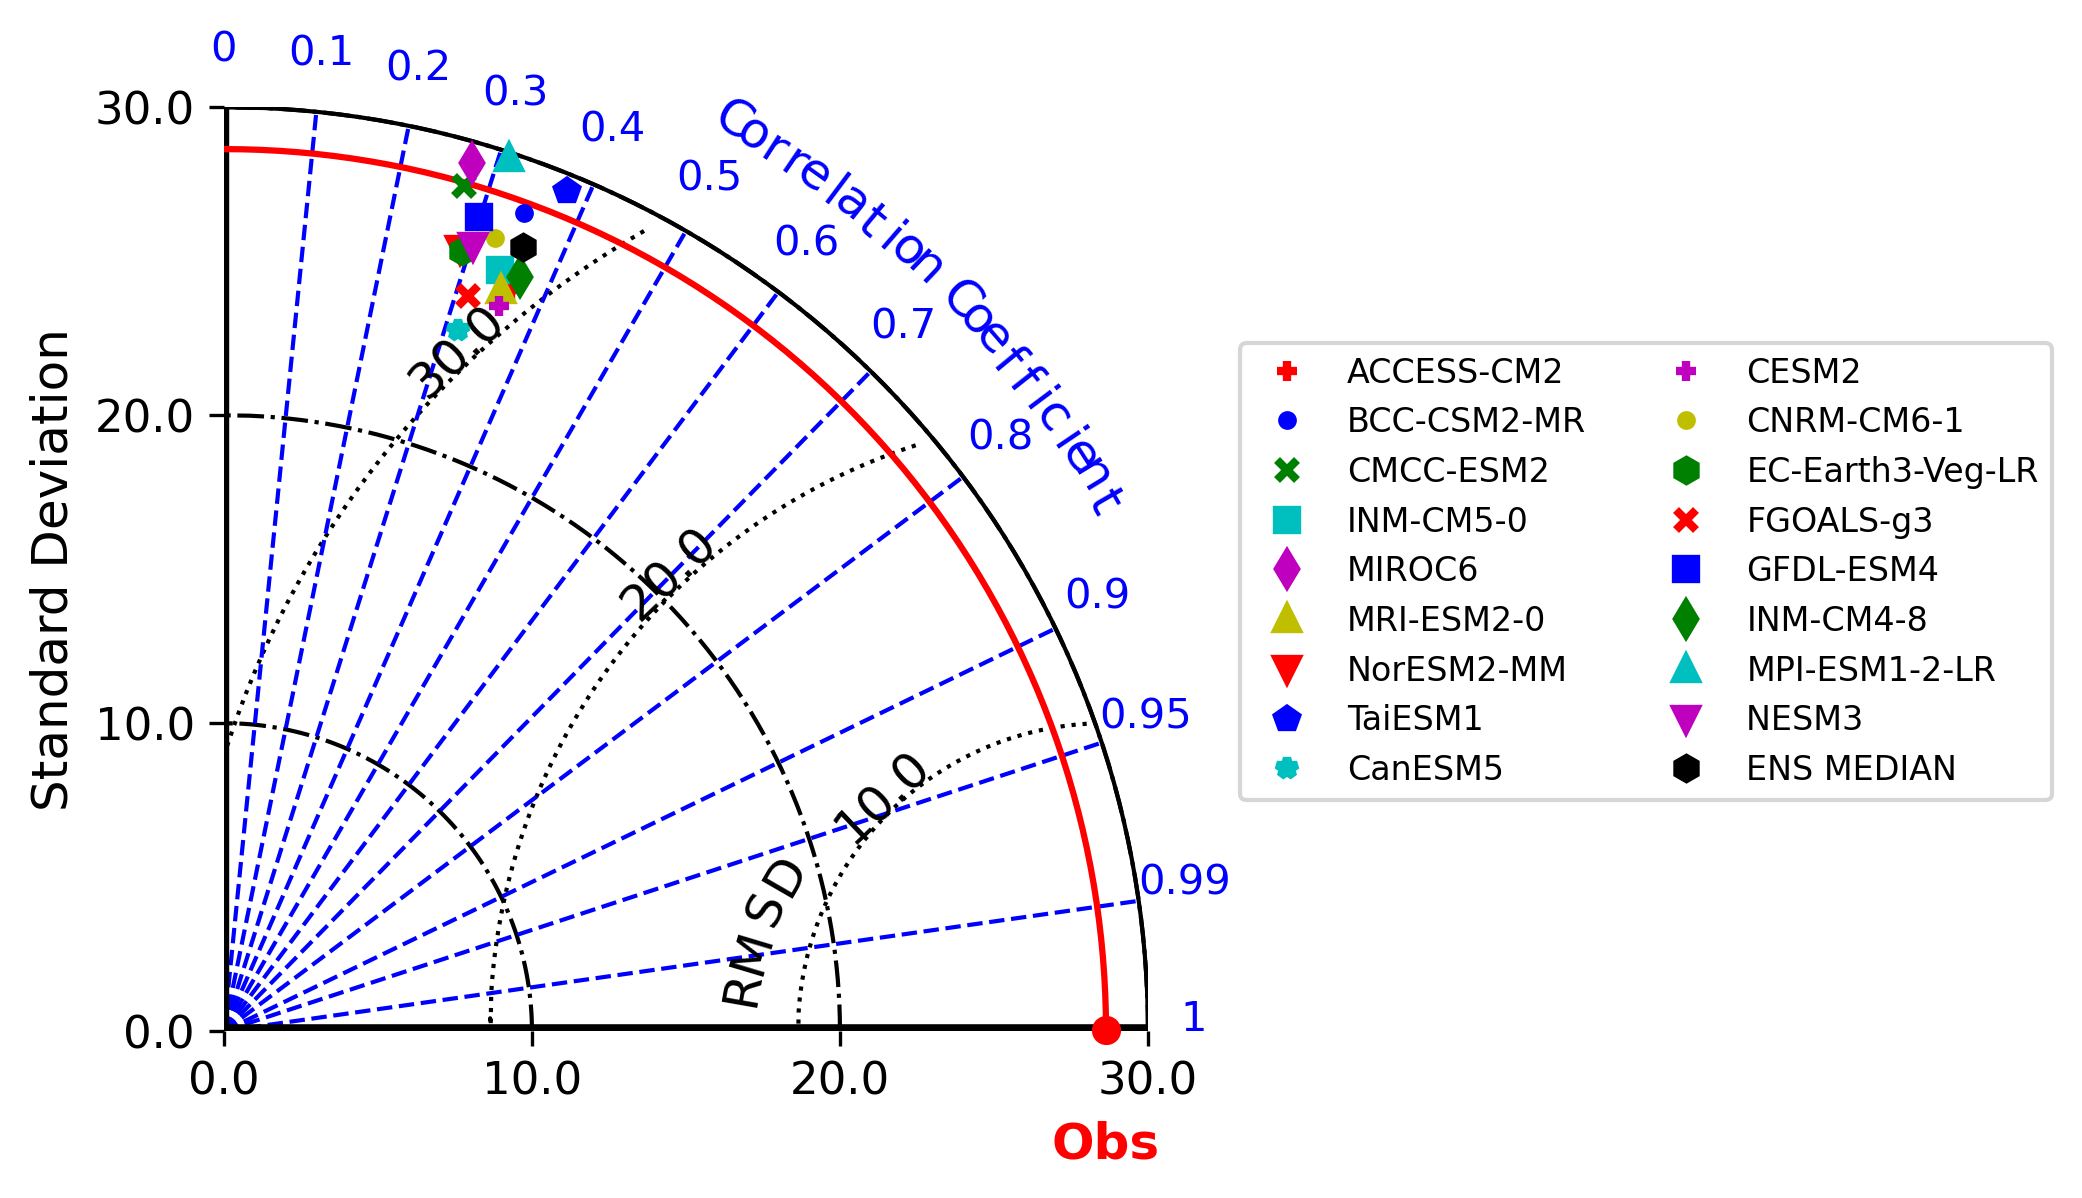

In [26]:
plt.figure(num=1, figsize=(8, 4),dpi=300)
sm.taylor_diagram(sdev,rmse,ccoef, markers = MARKERS, 
                markerLegend = 'on', styleOBS = '-', colOBS = 'r', markerobs = 'o',
                  markerLabelColor='black', markerSize=10,
                  labelweight='normal',
                      #tickRMS =[0.0, 1,2,3, 4] , tickRMSangle = 115.0, showlabelsRMS = 'on',
                      colRMS = 'k', styleRMS = ':', widthRMS = 1.0, titleRMS='on',
                    colSTD = 'k', styleSTD = '-.', widthSTD = 1.0, titleSTD ='on',
                      colCOR = 'b', styleCOR = '--', widthCOR = 1.0,titleCOR='on',
                       titleOBS = 'Obs')



#plt.title('Model performance against daily gridded precipitation Oulujoki Basin', y=1.15,loc='center')

plt.savefig(f'{DATADIR}prec_bc_taylor.png')
plt.show()
plt.close()

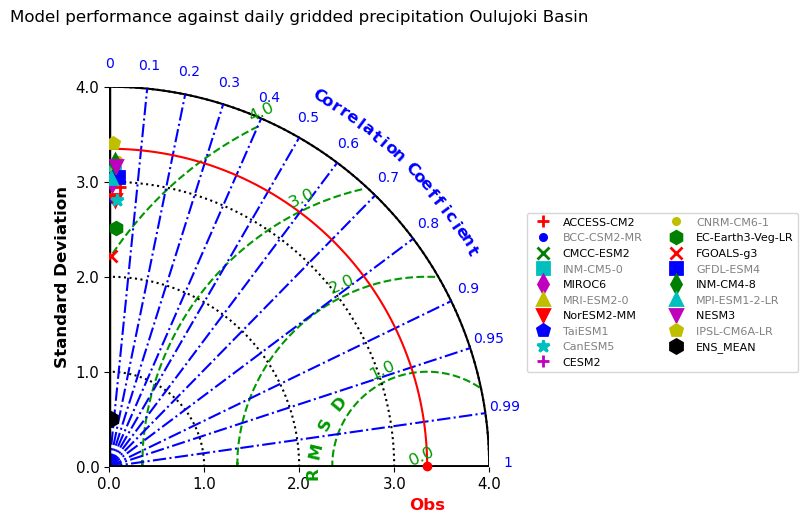

In [8]:
plt.figure(num=1, figsize=(8, 8))
sm.taylor_diagram(sdev,rmse,ccoef, markers = MARKERS, 
                      markerLegend = 'on', styleOBS = '-', colOBS = 'r', markerobs = 'o',
                      tickRMS = [0.0, 1.0,2.0, 3.0, 4.0],
                      tickRMSangle = 115, showlabelsRMS = 'on',
                      titleRMS = 'on',
                       titleOBS = 'Obs')

plt.title('Model performance against daily gridded precipitation Oulujoki Basin', y=1.15,loc='center')

plt.savefig('prec_taylor.png')
plt.show()
plt.close()

### Comparing the performance of bias-correction methods

In [51]:
data2 = pd.read_excel(path)
data2

,Models,R2,MAE,St.dev,RMSE
0,OBS,1.000000,0.000000,3.347193,0.000000
1,ENS_MEAN,0.031801,1.783595,0.502989,3.474400
2,QDM,0.022688,2.607067,3.305376,4.625731
3,EQM,0.022784,2.607543,3.298135,4.620517
4,LOCI,0.024454,2.078467,1.672132,3.726192
5,SCALING,0.058404,2.168743,1.234984,3.468875


In [52]:
sdev = data2['St.dev'].to_numpy()
rmse = data2['RMSE'].to_numpy()
ccoef = data2['R2'].to_numpy()
gageID = data2['Models'].to_list()

# Specify labels for points in a cell array using gage ID.
label = gageID
label

['OBS', 'ENS_MEAN', 'QDM', 'EQM', 'LOCI', 'SCALING']

In [53]:
MARKERS = {
        "ENS_MEAN": {
            "labelColor": "k",
            "symbol": ".",
            "size": 9,
            "faceColor": "r",
            "edgeColor": "r",
        },
        "QDM": {
            "labelColor": "k",
            "symbol": ".",
            "size": 9,
            "faceColor": "b",
            "edgeColor": "b",
        },
        "EDM": {
            "labelColor": "k",
            "symbol": ".",
            "size": 9,
            "faceColor": "g",
            "edgeColor": "g",
        },
        "LOCI": {
            "labelColor": "k",
            "symbol": ".",
            "size": 9,
            "faceColor": "c",
            "edgeColor": "c",
        },
        "SCALING": {
            "labelColor": "k",
            "symbol": ".",
            "size": 9,
            "faceColor": "m",
            "edgeColor": "m",
        },
        
    
        
    }

In [54]:
ncol = 2
if ncol == 1:
    sdev1 = sdev[0:11]
    rmse1= rmse[0:11]
    ccoef1 = ccoef[0:11]
    gageID1 = gageID[0:11]
elif ncol == 2:
    sdev1 = sdev
    rmse1 = rmse
    ccoef1 = ccoef
    gageID1 = gageID
else:
    sdev1 = sdev
    rmse1 = rmse
    ccoef1= ccoef
    gageID1 = data.gageID
    sdev1 = np.append(sdev1,sdev[1:11])
    rmse1 = np.append(rmse1,rmse[1:11])
    ccoef1 = np.append(ccoef1,ccoef[1:11])
    gageID1 = gageID1 + gageID[1:11]

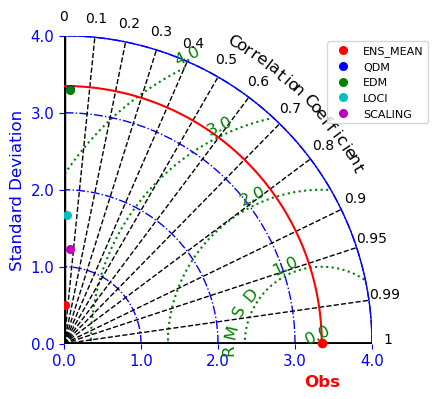

In [56]:
plt.figure(num=1, figsize=(5, 4))
sm.taylor_diagram(sdev,rmse,ccoef, markers = MARKERS, 
                      markerLegend = 'on', styleOBS = '-', colOBS = 'r', markerobs = 'o',
                  markerLabelColor='black', markerSize=10,
                  labelweight='normal',
                      tickRMS =[0.0, 1.0,2.0,3,4] , tickRMSangle = 115.0, showlabelsRMS = 'on',
                      colRMS = 'g', styleRMS = ':', widthRMS = 1.5, titleRMS='on',
                    colSTD = 'b', styleSTD = '-.', widthSTD = 1.0, titleSTD ='on',
                      colCOR = 'k', styleCOR = '--', widthCOR = 1.0,titleCOR='on',
                       titleOBS = 'Obs')



#plt.title('Model performance against daily gridded precipitation Oulujoki Basin', y=1.15,loc='center')

plt.savefig('prec_taylor_day_BC.png')
plt.show()
plt.close()

# References 
Taylor plots were plotted using skill metrics

1. Rochford, P.A., 2016. SkillMetrics: A Python package for calculating the skill of model predictions against observations [WWW Document]. URL 〈https://github.com/
PeterRochford/SkillMetrics〉 (accessed 10.13.23).

